# **Mestrado em Ciência de Dados - 2.º Ano**
**Aluno:** Miguel Loureiro | 2220134

**Instituição:** Universidade de Leiria e Oeste  

***Dissertação:*** Data Mining Aplicado à Transformação Digital de uma PME Portuguesa de E-commerce: Um Caso de Estudo Integrado

---

# **Notebook 5. Clustering | K-Means - Segmentação de Clientes por Portfólio de Produto**
*O presente notebook engloba a fase de Modelação da CRISP-DM, na qual é apresentado um problema de clustering aplicado à segmentação de clientes da PME em estudo, com base na composição do seu perfil de consumo ao nível de portfólio de produtos.*

---

## **Contextualização do problema em estudo**

### **Problema de negócio**

Identificar segmentos de clientes com perfil comportamental distinto relativamente ao portfólio de produtos que adquirem, permitindo à empresa personalizar e direcionar os esforços de comunicação de marketing por perfil de consumo e priorizar esforços comerciais de acordo com o valor e a especialização de cada segmento.

### **Formulação do problema de clustering**

**Tarefa:** Clustering, que permite o agrupamento de clientes recorrentes (com pelo menos 2 compras) em segmentos acionáveis com base na composição do seu portfólio de consumo e em variáveis comportamentais.

**Dimensão:** Clientes recorrentes da base completa.

**Features:** 21 variáveis que combinam três dimensões analíticas (15 *shares* de gasto por Tipo de produto que são calculadas neste notebook a partir de `df_linhas`, 3 variáveis de diversidade (`Num_Tipos`, `Num_Categorias`, `Num_Marcas`) e 3 variáveis de padrão de consumo (`Frequency`, `Monetary`, `Ticket_Medio`).

**Métrica principal:** *Silhouette Score*, oferecendo uma análise quantitativa, mas que é complementado pela análise da curva *Elbow* (WCSS) para a escolha do número de clusters.

### **Algoritmo aplicado**

| Algoritmo | Tipo | Justificação |
|---|---|---|
| **K-Means** | Baseado em centróides | Algoritmo comum em clustering em problemas de elevada dimensionalidade, sendo computacionalmente eficiente sobre datasets desta dimensão.|

### **Caracterização do notebook**

O presente notebook é o primeiro dos três notebooks que retratam o trabalho desenvolvido na componente de clustering desta dissertação. Neste notebook é aplicado o algoritmo K-Means sobre o portfólio de consumo dos clientes recorrentes, resultando numa segmentação que permite uma abordagem complementar e comparativa em relação aos resultados a obter em clustering hierárquico (NB6) para validação cruzada inter-método e em clustering RFM (NB7) para análise integrada das duas dimensões analíticas (portfólio × ciclo de vida).

### **Boas práticas adotadas**

- **`StandardScaler` aplicado após filtragem da base de clientes recorrente** - a normalização é apenas aplicada sobre os clientes que efetivamente entram no algoritmo.
- **Reutilização de *features* do `df_clientes_enriquecido`** - a utilização das variáveis de diversidade e de padrão de consumo criadas anteriormente na fase de preparação de dados evita a duplicação de procedimentos, tornando mais eficiente e claro o desenvolvimento deste processo.
- **Filtro de clientes com pelo menos 2 compras** - exclui clientes com apenas 1 compra, mantendo coerência com os dois notebooks seguintes associados à componente de clustering (NB6 e o NB7) e evita a criação de um cluster predominante e sem valor acrescentado composto apenas por clientes que realizaram 1 compra.
- **Determinação do *k* (nº de clusters) ótimo combinando Elbow e Silhouette Score** - permite complementar a vertente quantitativa com uma abordagem qualitativa.
- **Partilha do *dataset* de variáveis com o NB6** - exportação do `dataset_features_clustering.csv` no final da filtragem do universos de clientes neste notebook evita a duplicação dos procedimentos a realizar no próximo notebook, onde é utilizado exatamente o mesmo conjunto de features e universo de clientes.

---

## **Estrutura do notebook**

1. Importação de bibliotecas
2. Carregamento dos dados
3. Construção das features do espaço de clustering
   - 3.1. Shares de gasto por Tipo de produto
   - 3.2. Diversidade do portfólio
   - 3.3. Padrão de consumo
   - 3.4. Construção do dataset preliminar
4. Filtragem do universo com clientes recorrentes (2+ compras)
   - 4.1. Exportação do dataset de features para reutilização no NB6
5. Normalização das features
6. Determinação do k ótimo com método Elbow + Silhouette Score
7. Treino do modelo final
8. Caracterização dos clusters
   - 8.1. Perfil médio por cluster
   - 8.2. Heatmap dos perfis normalizados
   - 8.3. Dimensão de cada cluster
9. Visualização ilustrativa
10. Exportação dos resultados de clustering
11. Síntese

### **Outputs deste notebook**

- **`dataset_features_clustering.csv`** - dataset de features filtrado, reutilizado no NB6 para evitar duplicação de código.
- **`dataset_clusters_kmeans.csv`** - atribuição de cluster por `Ref Cliente`, que será utilizado no NB6 para validação inter-método e no NB7 para cruzamento entre as abordagens RFM e portfólio.
- **`kmeans_final.pkl`** - modelo K-Means treinado e scaler, persistidos para reaplicação a dados futuros.


## **1. Importação de bibliotecas**

O presente notebook inicia-se com a importação das bibliotecas necessárias à manipulação dos dados, criação das variáveis essenciais, normalização, aplicação do algoritmo K-Means, cálculo das métricas de avaliação, visualização e persistência do modelo final.

In [ ]:
#Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

#Pré-processamento e algoritmo de clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## **2. Carregamento dos dados**

O carregamento dos dados é realizado através dos dois dataframes complementares produzidos pelos notebooks anteriores:

- **`df_linhas`** exportado pelo NB1, com granularidade ao nível da linha de produto, sendo essencial para calcular as variáveis associadas a shares/quotas de gasto por Tipo de Produto.
- **`df_clientes_enriquecido`** exportado pelo NB2, que engloba as variáveis `Frequency`, `Monetary`, `Ticket_Medio` e as restantes variáveis de diversidade criadas previamente.

In [ ]:
#Montar Drive e carregar os dois dataframes da pipeline
from google.colab import drive
drive.mount('/content/drive')

#df_linhas - necessário para o cálculo dos shares por Tipo
df = pd.read_csv('/content/drive/MyDrive/df_linhas.csv')
df['Data'] = pd.to_datetime(df['Data'])

#df_clientes_enriquecido - produzido pelo NB3
df_clientes = pd.read_csv(
    '/content/drive/MyDrive/df_clientes_enriquecido.csv',
    parse_dates=['Ultima_Compra', 'Primeira_Compra']
)

print(f'df_linhas:               {df.shape}')
print(f'df_clientes_enriquecido: {df_clientes.shape}')

Mounted at /content/drive
df_linhas:               (152976, 18)
df_clientes_enriquecido: (13074, 17)


## **3. Construção das features do espaço de clustering**

Segue-se a criação das variáveis que integram três dimensões analíticas e que se distribuem por 21 variáveis no total:
- Composição do portfólio: 15 variáveis de *shares* (por exemplo, `share_Aves`, `share_Caes`)
- Diversidade: 3 variáveis (`Num_Tipos`, `Num_Categorias`, `Num_Marcas`)
- Padrão de consumo: 3 variáveis (`Frequency`, `Monetary`, `Ticket_Medio`)

### **3.1. Share de gasto por Tipo de produto**

Para cada cliente, calcula-se a percentagem do gasto total em cada Tipo de produto. A garantia de que a soma dos shares é 1 para cada cliente é assegurada pela normalização, permitindo a comparação entre shares independentemente do valor absoluto gasto.

Nas situações em que existem valores omissos na variável associada ao Tipo de produto, esses registos são agrupados no Tipo "Outros".

In [ ]:
#Tratar valores em falta - produtos sem Tipo são agrupados em 'Outros'
df['Tipo'] = df['Tipo'].fillna('Outros')

#Calcular gasto por cliente e por Tipo via pivot_table
gasto_por_tipo = df.pivot_table(
    index='Ref Cliente',
    columns='Tipo',
    values='Preço Produto c/IVA',
    aggfunc='sum',
    fill_value=0
)

#Normalizar: dividir o gasto em cada Tipo pelo gasto total do cliente
total_por_cliente = gasto_por_tipo.sum(axis=1)
share_por_tipo = gasto_por_tipo.div(total_por_cliente, axis=0)

#Renomear colunas com prefixo 'share_'
share_por_tipo.columns = ['share_' + col.replace(' ', '_').replace('/', '_')
                          for col in share_por_tipo.columns]

print(f'Dimensão da matriz de shares: {share_por_tipo.shape}')
print(f'\nTipos identificados: {list(share_por_tipo.columns)}')

Dimensão da matriz de shares: (13074, 15)

Tipos identificados: ['share_Aves_', 'share_Cercas_Elécticas', 'share_Controlo_de_Pragas', 'share_Cães', 'share_Gatos', 'share_Incubadoras', 'share_Jardim_Agricultura', 'share_Material_de_Proteção', 'share_Moinhos_Depenadoras', 'share_Máquinas', 'share_Outros', 'share_Pecuária', 'share_Pombos', 'share_Roedores', 'share_Ulilidades']


### **3.2. Features de diversidade do portfólio**

As variáveis de diversidade (`Num_Tipos`, `Num_Categorias`, `Num_Marcas`) foram criadas na fase de preparação de dados (NB2) e estão incluídas no dataset `df_clientes_enriquecido`.

In [ ]:
#Validação das features de diversidade que provêm da fase de preparação de dados
assert 'Num_Tipos' in df_clientes.columns, 'Num_Tipos ausente - verificar export do NB3'
assert 'Num_Categorias' in df_clientes.columns, 'Num_Categorias ausente - verificar export do NB3'
assert 'Num_Marcas' in df_clientes.columns, 'Num_Marcas ausente - verificar export do NB3'

print(df_clientes[['Num_Tipos', 'Num_Categorias', 'Num_Marcas']].describe().round(2))

       Num_Tipos  Num_Categorias  Num_Marcas
count   13074.00        13074.00    13074.00
mean        1.28            2.58        2.93
std         0.81            3.14        4.51
min         0.00            0.00        0.00
25%         1.00            1.00        1.00
50%         1.00            1.00        1.00
75%         1.00            3.00        3.00
max        11.00           35.00       58.00


### **3.3. Features de padrão de consumo**

Tal como acontece nas variáveis de diversidade, as variáveis de padrão de consumo (`Frequency`, `Monetary`, `Ticket_Medio`) também provêm do NB2.

In [ ]:
#Padrão de consumo já presente em df_clientes_enriquecido
padrao_consumo = df_clientes[['Ref Cliente', 'Frequency', 'Monetary', 'Ticket_Medio']].copy()
padrao_consumo = padrao_consumo.set_index('Ref Cliente')

print(padrao_consumo.describe().round(2))

       Frequency  Monetary  Ticket_Medio
count   13074.00  13074.00      13074.00
mean        4.28    292.15         59.00
std         9.56    849.57         56.64
min         1.00      2.40          2.40
25%         1.00     35.40         28.14
50%         1.00     68.70         47.34
75%         3.00    192.50         69.99
max       174.00  18431.09       1577.00


### **3.4. Construção do dataset preliminar**

De seguida, procede-se à criação do dataset indexado pela variável `Ref Cliente`, onde são incluídas todas as 21 features das três dimensões analíticas.

In [ ]:
#Combinar todas as features num único dataframe
df_clusters = share_por_tipo.copy()

#Diversidade - incluir diretamente do df_clientes_enriquecido
diversidade = df_clientes.set_index('Ref Cliente')[['Num_Tipos', 'Num_Categorias', 'Num_Marcas']]
df_clusters = df_clusters.join(diversidade, how='left')

#Padrão de consumo
df_clusters = df_clusters.join(padrao_consumo, how='inner')

#Preencher eventuais valores em falta com 0
df_clusters = df_clusters.fillna(0)

print(f'Dimensão do dataset preliminar: {df_clusters.shape}')
print(f'\nFeatures: {list(df_clusters.columns)}')

Dimensão do dataset preliminar: (13074, 21)

Features: ['share_Aves_', 'share_Cercas_Elécticas', 'share_Controlo_de_Pragas', 'share_Cães', 'share_Gatos', 'share_Incubadoras', 'share_Jardim_Agricultura', 'share_Material_de_Proteção', 'share_Moinhos_Depenadoras', 'share_Máquinas', 'share_Outros', 'share_Pecuária', 'share_Pombos', 'share_Roedores', 'share_Ulilidades', 'Num_Tipos', 'Num_Categorias', 'Num_Marcas', 'Frequency', 'Monetary', 'Ticket_Medio']


## **4. Filtragem do universo - clientes recorrentes (2+ compras)**

Na fase de Compreensão do Negócio estabeleceu-se que a componente de clustering apenas é desenvolvida tendo em consideração a base de clientes com pelo menos **2 compras**. Esta escolha justifica-se pelo facto de que a inclusão dos clientes com apenas 1 compra levaria à criação de um cluster artificial e dominante.

In [ ]:
#Guardar a versão completa para eventual análise comparativa posterior
df_clusters_todos = df_clusters.copy()

#Filtrar para reter apenas clientes recorrentes (Frequency >= 2)
df_clusters = df_clusters[df_clusters['Frequency'] >= 2].copy()

#Validar o universo final
n_total = len(df_clusters_todos)
n_recorrentes = len(df_clusters)
n_excluidos = n_total - n_recorrentes

print(f'Clientes na base completa:         {n_total}')
print(f'Clientes com 1 compra (excluídos):  {n_excluidos}')
print(f'Clientes recorrentes (mantidos):   {n_recorrentes}')
print(f'\nProporção do universo filtrado: {n_recorrentes/n_total:.1%}')

Clientes na base completa:         13074
Clientes com 1 compra (excluídos):  7553
Clientes recorrentes (mantidos):   5521

Proporção do universo filtrado: 42.2%


A aplicação do filtro resulta numa redução da base de clientes de 13.074 para 5.521 clientes recorrentes, correspondendo assim a 42,2% da base completa, menos de metade. Desta forma, os 5.521 clientes recorrentes representam a base de clientes a ter em conta em toda a componente analítica de clustering desenvolvida nos três notebooks de clustering.

### **4.1. Exportação do dataset de features para reutilização no NB6**

O dataset resultante da aplicação do filtro de clientes recorrentes com pelo menos 2 compras traduz-se em 5.521 clientes recorrentes e num conjunto de 21 features. Este dataset é, neste ponto, exportado para que seja possível a sua reutilização direta no notebook seguinte (NB6) onde será aplicado Clustering Hierárquico, partilhando exatamente o mesmo conjunto de variáveis.

A escolha de exportar na escala original, ou seja, antes da normalização, justifica-se pela necessidade de:

- **Preservação da escala** para a caracterização dos clusters na secção 8, onde se pretende uma análise e identificação do perfil médio de cada cluster em valores reais.
- **Flexibilidade** para o NB6 aplicar o seu próprio `StandardScaler`.


In [ ]:
#Exportar dataset filtrado para reutilização no NB6 (Clustering Hierárquico)
#A escala mantém-se original, pois a normalização é aplicada em cada notebook
df_clusters.to_csv('/content/drive/MyDrive/dataset_features_clustering.csv')

print(f'Dataset exportado: dataset_features_clustering.csv')
print(f'Dimensão: {df_clusters.shape[0]:,} clientes × {df_clusters.shape[1]} features'.replace(',', '.'))

Dataset exportado: dataset_features_clustering.csv
Dimensão: 5.521 clientes × 21 features


## **5. Normalização das features**

Como expectável, as variáveis que integram o conjunto de dados apresentam escalas diferentes, sendo necessária a aplicação de `StandardScaler` para que todas as variáveis sejam convertidas para a mesma escala (média = zero e variância = 1).

In [ ]:
#Normalização das features
scaler = StandardScaler()
X = scaler.fit_transform(df_clusters)

print(f'Dimensão de X após normalização: {X.shape}')

Dimensão de X após normalização: (5521, 21)


## **6. Determinação do k ótimo - Elbow + Silhouette**

A escolha do número de clusters é realizada por via da conjugação da análise entre o método Elbow (WCSS) e o Silhouette Score, sendo ambos calculados para valores de k entre 2 e 10, evitando assim a definição de um só cluster e de mais do que dez, que traduziria um número limitado ou excessivo de clusters. Segue-se a apresentação das curvas de ambos os indicadores e a apresentação das métricas para cada k.

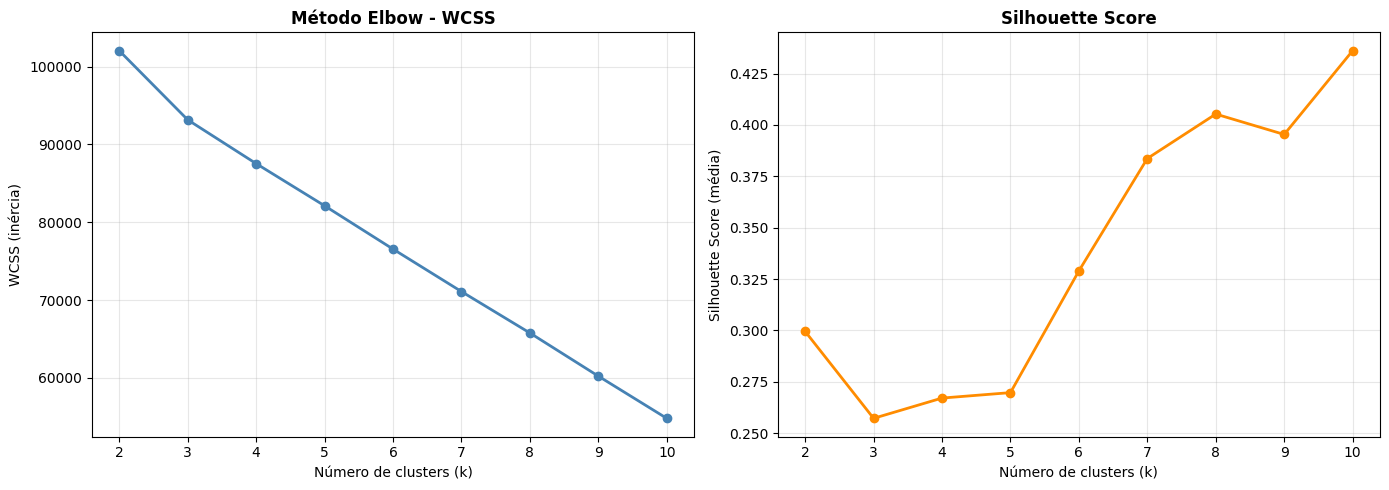


Valores numéricos:
  k=2: WCSS = 102046.29   |   Silhouette = 0.2995
  k=3: WCSS =  93168.03   |   Silhouette = 0.2572
  k=4: WCSS =  87542.88   |   Silhouette = 0.2671
  k=5: WCSS =  82126.81   |   Silhouette = 0.2697
  k=6: WCSS =  76561.63   |   Silhouette = 0.3289
  k=7: WCSS =  71105.28   |   Silhouette = 0.3836
  k=8: WCSS =  65785.51   |   Silhouette = 0.4053
  k=9: WCSS =  60241.49   |   Silhouette = 0.3953
  k=10: WCSS =  54816.58   |   Silhouette = 0.4361

k com maior Silhouette: 10


In [ ]:
#Calcular WCSS e Silhouette Score para k entre 2 e 10
ks = range(2, 11)
wcss = []
silhouettes = []

for k in ks:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = modelo.fit_predict(X)
    wcss.append(modelo.inertia_)
    silhouettes.append(silhouette_score(X, labels))

#Visualizar Elbow e Silhouette lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(ks), wcss, marker='o', linewidth=2, color='steelblue')
axes[0].set_title('Método Elbow - WCSS', fontweight='bold')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('WCSS (inércia)')
axes[0].set_xticks(list(ks))
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(ks), silhouettes, marker='o', linewidth=2, color='darkorange')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette Score (média)')
axes[1].set_xticks(list(ks))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nValores numéricos:')
for k, w, s in zip(ks, wcss, silhouettes):
    print(f'  k={k}: WCSS = {w:9.2f}   |   Silhouette = {s:.4f}')

print(f'\nk com maior Silhouette: {list(ks)[silhouettes.index(max(silhouettes))]}')

**Interpretação dos critérios de seleção do k**

Os valores obtidos foram os seguintes:

| k | WCSS | Silhouette Score |
|---|---|---|
| 2 | 102.046,29 | 0,2995 |
| 3 | 93.168,03 | 0,2572 |
| 4 | 87.542,88 | 0,2671 |
| 5 | 82.126,81 | 0,2697 |
| 6 | 76.561,63 | 0,3289 |
| **7** | **71.105,28** | **0,3836** |
| 8 | 65.785,51 | 0,4053 |
| 9 | 60.241,49 | 0,3953 |
| 10 | 54.816,58 | 0,4361 |

Os resultados obtidos pelo Silhouette Score demonstram que o número selecionado de clusters corresponde a **7** como compromisso entre a métrica estatística em questão e a operacionalidade efetiva dos segmentos, tendo sido obtido um score de **0,3836**. Esta seleção justifica-se pelo facto de a análise da curva do Silhouette evidenciar o maior salto absoluto entre k=6 (0,3289) e k=7 (0,3836), representado por um aumento de +0,0547. Embora k=10 apresente o Silhouette mais elevado (0,4361), a seleção desse valor faria com que alguns desses segmentos ficassem excessivamente pequenos, culminando numa dificuldade adicional na operacionalização das ações de marketing personalizadas e segmentadas.

## **7. Treino do modelo final**

A seleção de k = 7 permite avançar para o treino do modelo final `KMeans(n_clusters=7, random_state=42, n_init=10)`.

In [ ]:
#Definir k_otimo escolhido
k_otimo = 7

#Treinar KMeans final
modelo_kmeans = KMeans(n_clusters=k_otimo, random_state=42, n_init=10)
df_clusters['Cluster'] = modelo_kmeans.fit_predict(X)

#Apresentar Silhouette final e distribuição
silhouette_final = silhouette_score(X, df_clusters['Cluster'])
print(f'Silhouette Score do modelo final (k={k_otimo}): {silhouette_final:.4f}')
print(f'\nDistribuição dos clientes por cluster:')
print(df_clusters['Cluster'].value_counts().sort_index())

Silhouette Score do modelo final (k=7): 0.3836

Distribuição dos clientes por cluster:
Cluster
0    2778
1    1352
2     151
3     575
4      50
5     500
6     115
Name: count, dtype: int64


**Análise da distribuição dos clusters**

O treino do modelo K-Means com k=7 deu origem à seguinte distribuição, tendo em conta os 5.521 clientes recorrentes:

| Cluster | N | % | Característica |
|---|---|---|---|
| 0 | 2.778 | 50,32% | Maior cluster - pouco mais de metade da base |
| 1 | 1.352 | 24,49% | Segundo maior cluster |
| 2 | 151 | 2,74% | Nicho de pequena-média dimensão |
| 3 | 575 | 10,41% | Cluster de média dimensão e alto valor |
| 4 | 50 | 0,91% | Nicho de pequena dimensão |
| 5 | 500 | 9,06% | Cluster de média dimensão |
| 6 | 115 | 2,08% | Nicho de pequena dimensão |

## **8. Caracterização dos clusters**

A caracterização dos clusters identificados conjuga três abordagens: perfil médio em valores absolutos, heatmap normalizado e dimensão de cada cluster.

### **8.1. Perfil médio por cluster**

In [ ]:
#Perfil médio de cada cluster
perfil_clusters = df_clusters.groupby('Cluster').mean().round(3)
print('Perfil médio dos clusters:')
perfil_clusters

Perfil médio dos clusters:


,share_Aves_,share_Cercas_Elécticas,share_Controlo_de_Pragas,share_Cães,share_Gatos,share_Incubadoras,share_Jardim_Agricultura,share_Material_de_Proteção,share_Moinhos_Depenadoras,share_Máquinas,...,share_Pecuária,share_Pombos,share_Roedores,share_Ulilidades,Num_Tipos,Num_Categorias,Num_Marcas,Frequency,Monetary,Ticket_Medio
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.910,0.000,0.003,0.018,0.007,0.002,0.003,0.016,0.000,0.001,...,0.019,0.004,0.003,0.000,1.396,4.423,5.164,5.632,322.509,55.398
1,0.017,0.000,0.095,0.741,0.021,0.009,0.004,0.002,0.000,0.001,...,0.004,0.000,0.002,0.000,1.297,1.696,2.027,5.743,405.330,67.218
2,0.035,0.000,0.004,0.007,0.012,0.002,0.002,0.002,0.000,0.000,...,0.001,0.000,0.932,0.000,1.536,2.901,2.318,8.079,423.630,47.412
3,0.822,0.001,0.010,0.089,0.026,0.002,0.008,0.002,0.000,0.000,...,0.007,0.003,0.007,0.001,3.640,13.120,18.687,36.261,2925.026,81.512
4,0.039,0.895,0.006,0.016,0.004,0.000,0.021,0.009,0.003,0.000,...,0.005,0.000,0.000,0.000,1.620,3.300,1.300,3.160,461.476,168.759
5,0.011,0.000,0.002,0.043,0.918,0.000,0.003,0.000,0.000,0.000,...,0.002,0.001,0.001,0.000,1.322,1.802,2.052,4.924,323.749,61.405
6,0.010,0.000,0.029,0.006,0.008,0.000,0.905,0.015,0.000,0.000,...,0.004,0.000,0.003,0.018,1.496,1.870,1.557,2.765,161.355,62.892


### **8.2. Heatmap dos perfis (normalizados)**

Segue-se a apresentação do heatmap com as médias normalizadas (*z-score*) das features por cluster.

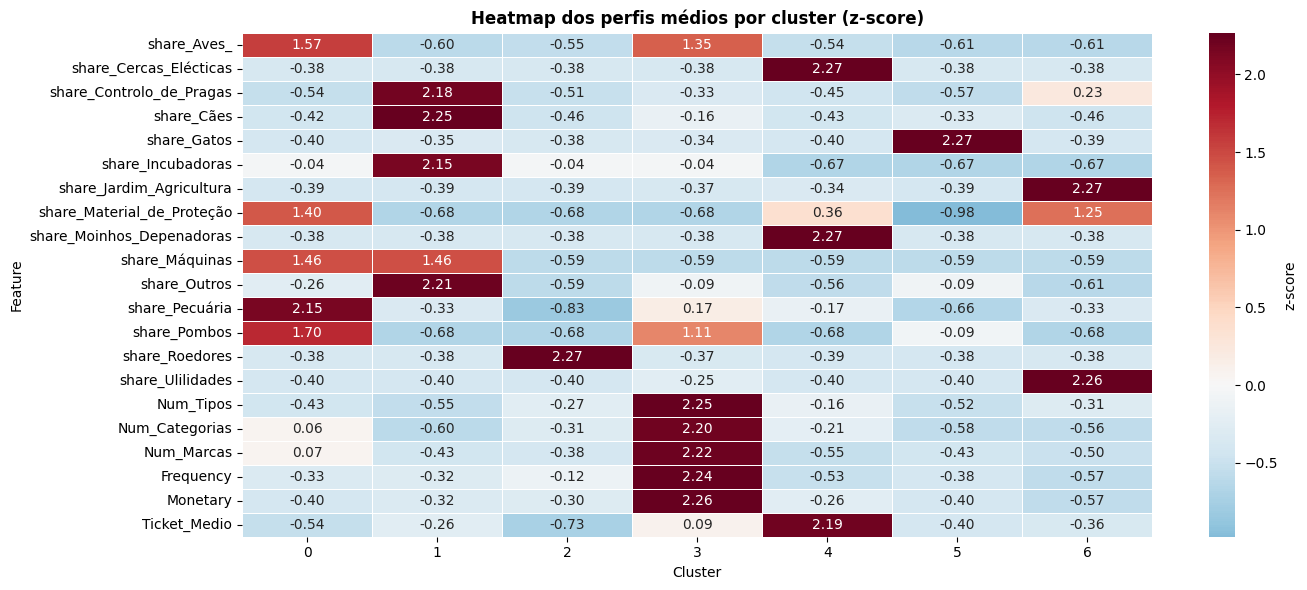

In [ ]:
#Calcular z-score por feature para o heatmap
perfil_normalizado = (perfil_clusters - perfil_clusters.mean()) / perfil_clusters.std()

#Heatmap dos perfis normalizados
plt.figure(figsize=(14, 6))
sns.heatmap(
    perfil_normalizado.T,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'z-score'}
)
plt.title('Heatmap dos perfis médios por cluster (z-score)', fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### **8.3. Dimensão de cada cluster**

A dimensão de cada cluster é apresentada de seguida, permitindo compreender quais os clusters com maior volume de clientes e quais são aqueles que representam nichos de clientes.

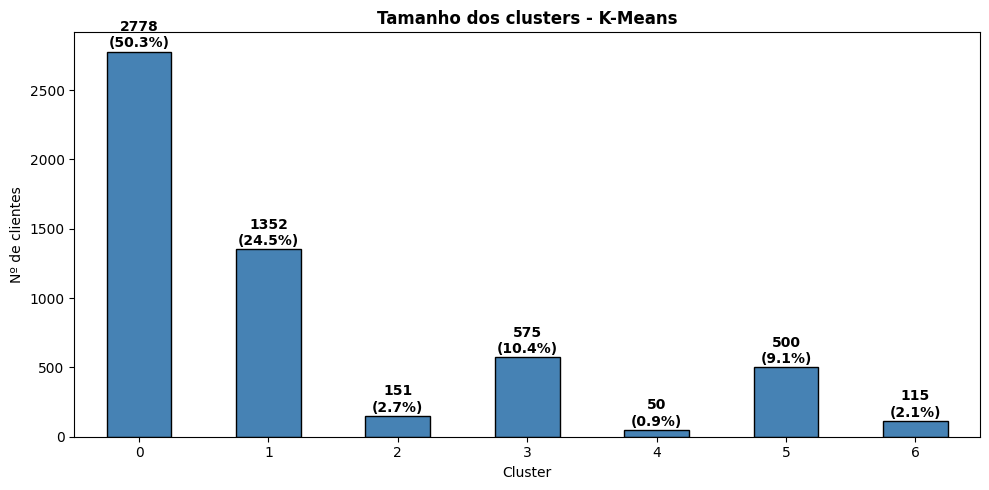


Proporção de clientes por cluster:
Cluster
0    50.32%
1    24.49%
2     2.74%
3    10.41%
4     0.91%
5     9.06%
6     2.08%
Name: proportion, dtype: object


In [ ]:
#Calcular dimensões
tamanhos = df_clusters['Cluster'].value_counts().sort_index()
proporcoes = df_clusters['Cluster'].value_counts(normalize=True).sort_index() * 100

#Visualização em gráfico de barras
plt.figure(figsize=(10, 5))
ax = tamanhos.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Tamanho dos clusters - K-Means', fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Nº de clientes')
plt.xticks(rotation=0)

for i, (n, p) in enumerate(zip(tamanhos.values, proporcoes.values)):
    ax.text(i, n + 30, f'{n}\n({p:.1f}%)', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nProporção de clientes por cluster:')
print(df_clusters['Cluster'].value_counts(normalize=True).sort_index().mul(100).round(2).astype(str) + '%')

**Interpretação dos clusters**

Os resultados obtidos demonstram que existem dois clusters diferentes (Cluster 0 – Avicultores Gerais e Cluster 3 – Avicultores VIP) com foco em clientes do segmento Aves. Enquanto o Cluster 0 é composto por um conjunto de 2.778 clientes (50,32%) com um valor total gasto médio na ordem dos 323€ e um ticket médio reduzido (55,40€), o Cluster 3 evidencia a existência de um grupo mais restrito, 575 clientes, representado por um valor médio gasto significativamente superior (2.925€), por uma frequência média de compras com valor igual a 36,26 e um ticket médio superior (81,51€).

Por isso, o Cluster 3 representa apenas 10,41% da totalidade da base de clientes com pelo menos 2 compras realizadas, no entanto consiste num segmento de valor acrescentado relevante para a empresa e que requer estratégias cuidadosamente planeadas, na medida em que o valor médio gasto, a frequência e o ticket médio são significativamente superiores ao registado no Cluster 0.

O Cluster 1 (Clientes de Cães) é representado por 24,5% da base de clientes,  constituindo o segundo maior segmento. Os três clusters de menor dimensão, Cluster 2 - Tutores de Roedores (2,7%), Cluster 6 - Compradores de Jardim (2,1%) e Cluster 4 - Compradores de Equipamento Agrícola (0,9%), são caracterizados como nichos comportamentalmente distintos com necessidades específicas de comunicação.

## **9. Visualização - Scatter ilustrativo**

A criação do scatter plot é sustentada pela seleção automática das duas variáveis `share_*` com maior variância, proporcionando uma projeção 2D do espaço de clustering (que opera em 21 dimensões).

Features escolhidas para o scatter: share_Aves_ vs share_Cães


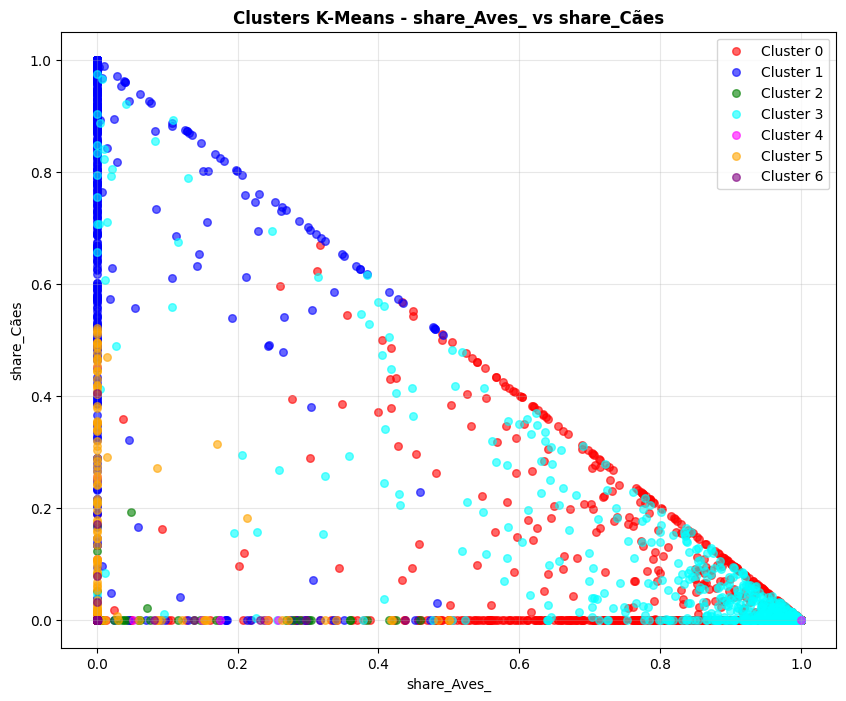

In [ ]:
#Escolher automaticamente as 2 features 'share_*' com maior variância
share_cols = [c for c in df_clusters.columns if c.startswith('share_')]
variancias = df_clusters[share_cols].var().sort_values(ascending=False)
col_x = variancias.index[0]
col_y = variancias.index[1]
print(f'Features escolhidas para o scatter: {col_x} vs {col_y}')

cores = ['red', 'blue', 'green', 'cyan', 'magenta', 'orange',
         'purple', 'brown', 'pink', 'gray']

plt.figure(figsize=(10, 8))
for c in range(k_otimo):
    mask = df_clusters['Cluster'] == c
    plt.scatter(
        df_clusters.loc[mask, col_x],
        df_clusters.loc[mask, col_y],
        s=30, c=cores[c], label=f'Cluster {c}', alpha=0.6
    )
plt.title(f'Clusters K-Means - {col_x} vs {col_y}', fontweight='bold')
plt.xlabel(col_x)
plt.ylabel(col_y)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### **Interpretação do *scatter***

O scatter plot desenvolvido no plano `share_Aves` × `share_Cães` demonstra uma separação clara entre os avicultores (clusters 0 e 3) e os clientes de cães (cluster 1). Os clusters mais especializados, como por exemplo Tutores de Gatos (5), Tutores de Roedores (2), Equipamento Agrícola (4) e Jardim (6), estão concentrados em redor da origem. Este resultado evidencia que a sua identidade depende de variáveis específicas não visíveis nesta projeção 2D.

## **10. Exportação dos resultados de clustering**

Este notebook culmina na exportação de dois outputs finais essenciais:

- **`dataset_clusters_kmeans.csv`** - dataframe `df_clusters` com a coluna `Cluster` adicionada, para utilização no NB6 que possibilita a validação cruzada inter-método e no NB7 onde é realizado o cruzamento entre as abordagens RFM e portfólio.
- **`kmeans_final.pkl`** - modelo K-Means treinado e scaler, persistidos com `joblib`.

In [ ]:
#Exportar dataset com clusters atribuídos
df_clusters.to_csv('/content/drive/MyDrive/dataset_clusters_kmeans.csv')
print('Dataset exportado: dataset_clusters_kmeans.csv')

#Garantir que a pasta /modelos existe
os.makedirs('/content/drive/MyDrive/modelos', exist_ok=True)

#Persistir o modelo e o scaler
joblib.dump(modelo_kmeans, '/content/drive/MyDrive/modelos/kmeans_final.pkl')
joblib.dump(scaler, '/content/drive/MyDrive/modelos/scaler_kmeans.pkl')
print('Modelo guardado: kmeans_final.pkl')
print('Scaler guardado: scaler_kmeans.pkl')

Dataset exportado: dataset_clusters_kmeans.csv
Modelo guardado: kmeans_final.pkl
Scaler guardado: scaler_kmeans.pkl


## **11. Síntese**

A aplicação do algoritmo K-Means permitiu a segmentação dos 5.521 clientes recorrentes em 7 grupos comportamentalmente distintos. Segue-se a apresentação dos resultados mais relevantes:

- **k=7 selecionado** com Silhouette de **0,3836**, que corresponde ao maior salto marginal da curva, embora não seja o valor registado mais elevado.

- **Dimensão assimétrica dos segmentos** com dois clusters dominantes (Avicultores Gerais 50,3% e Clientes de Cães 24,5%), dois segmentos intermédios (Avicultores VIP 10,4% e Tutores de Gatos 9,1%) e três nichos distintos.

- **Identificação do segmento de Avicultores VIP / Champions**, representado pelo Cluster 3 com 575 clientes. Este segmento apresenta elevada diversidade (Num_Categorias 13,1, Num_Marcas 18,7), elevada Frequency (36,3) e Monetary (2.925€). Este segmento representa o grupo com maior valor acrescentado para a empresa.